# **Time Series Analysis of Housing Market in Ames, Iowa**

## **Goal:**

__1. Do sales volumes and prices vary with the seasons?__

__2. In what ways have housing prices in Ames shifted over time, considering both market shocks and the age of homes?__



## **Introduction :**

Over the past few years, housing has changed a lot. Rising incomes, higher living costs, and homeowners wanting better upgrades have reshaped how houses are built and designed. Even rural areas have seen sharp price increases.

Usually when somebody considering to buy house consider the neighborhood, type of house, attributes of the house, type of sale, and time are factored into the price. We will try to understand these factors and  how they have affected the price of houses over time to see the change that was explained above.

The data was collected by De Cock where 81 dimensions were recorded for 1460 properties in Ames IA.

Brief description of columns:

**1. Identification**
- **Id:** Property ID (unique identifier).

__2. Sale Information__
- **SalePrice:** Target variable — final selling price.
- **SaleType:** Type of sale (e.g., Warranty Deed).
- **SaleCondition:** Condition of sale (Normal, Abnormal, Partial).

__3. Lot & Land__
- **MSSubClass:** Dwelling type (e.g., 1-story, 2-story).
- **MSZoning:** Zoning classification.
- **LotFrontage:** Street frontage length.
- **LotArea:** Lot size (sq ft).
- **Street:** Road access type.
- **Alley:** Alley access type.
- **LotShape:** Lot shape (Regular, Irregular).
- **LandContour:** Flatness of property.
- **Utilities:** Available utilities.
- **LotConfig:** Lot configuration (Corner, Inside).
- **LandSlope:** Slope of property.
- **Neighborhood:** Physical location within Ames.
- **Condition1/Condition2:** Proximity to roads, railways, etc.

__4. Building & Construction__

- **BldgType:** Building type (Single-family, Duplex).
- **HouseStyle:** House style (1-story, 2-story, split-level).
- **OverallQual:** Overall material/finish quality (1–10).
- **OverallCond:** Overall condition (1–10).
- **YearBuilt:** Year built.
- **YearRemodAdd:** Remodel year.
- **RoofStyle:** Roof type.
- **RoofMatl:** Roof material.
- **Exterior1st/Exterior2nd:** Exterior covering materials.
- **MasVnrType:** Masonry veneer type.
- **MasVnrArea:** Masonry veneer area (sq ft).
- **ExterQual:** Exterior quality.
- **ExterCond:** Exterior condition.

__5. Interior Features__

- **Foundation:** Foundation type.
- **BsmtQual:** Basement quality.
- **BsmtCond:** Basement condition.
- **BsmtExposure:** Basement exposure (walkout, garden).
- **BsmtFinType1/BsmtFinType2:** Basement finish types.
- **BsmtFinSF1/BsmtFinSF2:** Finished basement area (sq ft).
- **BsmtUnfSF:** Unfinished basement area.
- **TotalBsmtSF:** Total basement area.
- **Heating:** Heating type.
- **HeatingQC:** Heating quality.
- **CentralAir:** Central air (Y/N).
- **Electrical:** Electrical system.
- **1stFlrSF:** First floor area.
- **2ndFlrSF:** Second floor area.
- **LowQualFinSF:** Low-quality finished area.
- **GrLivArea:** Above-ground living area.
- **BsmtFullBath/BsmtHalfBath:** Basement bathrooms.
- **FullBath/HalfBath:** Bathrooms above ground.
- **BedroomAbvGr:** Bedrooms above ground.
- **KitchenAbvGr:** Kitchens above ground.
- **KitchenQual:** Kitchen quality.
- **TotRmsAbvGrd:** Total rooms above ground.
- **Functional:** Home functionality rating.
- **Fireplaces:** Number of fireplaces.
- **FireplaceQu:** Fireplace quality.

__6. Garage__
- **GarageType:** Garage location.
- **GarageYrBlt:** Year garage built.
- **GarageFinish:** Garage finish.
- **GarageCars:** Garage capacity (cars).
- **GarageArea:** Garage area (sq ft).
- **GarageQual:** Garage quality.
- **GarageCond:** Garage condition.

**7.Outdoor & Misc**

- **PavedDrive:** Paved driveway (Y/N).
- **WoodDeckSF:** Wood deck area (sq ft).
- **OpenPorchSF:** Open porch area.
- **EnclosedPorch:** Enclosed porch area.
- **3SsnPorch:** Three-season porch area.
- **ScreenPorch:** Screen porch area.
- **PoolArea:** Pool area (sq ft).
- **PoolQC:** Pool quality.
- **Fence:** Fence quality.
- **MiscFeature:** Miscellaneous features (shed, tennis court).
- **MiscVal:** Value of miscellaneous features.

__8. Living Space Totals__
- **MoSold:** Month sold.
- **YrSold:** Year sold.

**This dataset represents the sale of properties in Ames, Iowa, where every single record represents a sale of individual house.
There are identification, location, land lot information, house characteristics, exterior, interior, garge, sales information and other features describing each house. The house sales data spans from 2006 to 2010.**

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import sidetable
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

In [16]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import warnings
warnings.filterwarnings("ignore")
# set the decimal places to 2
pd.set_option("display.float_format", "{:.2f}".format)

In [17]:
path = Path.cwd().parent
data_path = path.joinpath("data", "raw")
files = []
for file in data_path.rglob("*.csv"):
    files.append(file)
    print(file.name)
    print(files.index(file), " ", file)

sample_submission.csv
0   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\sample_submission.csv
test.csv
1   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\test.csv
train.csv
2   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\train.csv


In [18]:
# Read train and test
df_train = pd.read_csv(files[2])
df_test = pd.read_csv(files[1])
print("Training Dataset:")
display(df_train.head(1))
print("\n")
print("Testing Dataset:")
display(df_test.head(1))


Training Dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500




Testing Dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.00,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,CBlock,TA,TA,No,Rec,468.00,LwQ,144.00,270.00,882.00,GasA,TA,Y,SBrkr,896,0,0,896,0.00,0.00,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.00,Unf,1.00,730.00,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal


In [19]:
# Basic info of datasets
print(f"Training Dataset Shape : {df_train.shape}")
print(f"Testing Dataset Shape : {df_test.shape}")


Training Dataset Shape : (1460, 81)
Testing Dataset Shape : (1459, 80)


In [20]:
# remove whitespace from columns name, replace space to '_' for columns name for conveince

df_train.columns = df_train.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")#.str.lower()
df_test.columns = df_test.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

In [21]:
dtype_df = pd.DataFrame(index=df_train.columns, columns=['Dtype','nunique','unique'])
dtype_df['Dtype'] = df_train.dtypes
dtype_df['nunique'] = df_train.nunique()
dtype_df['unique'] = [df_train[col].unique() for col in df_train.columns]
dtype_df


,Dtype,nunique,unique
Id,int64,1460,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
MSSubClass,int64,15,"[60, 20, 70, 50, 190, 45, 90, 120, 30, 85, 80,..."
MSZoning,object,5,"[RL, RM, C (all), FV, RH]"
LotFrontage,float64,110,"[65.0, 80.0, 68.0, 60.0, 84.0, 85.0, 75.0, nan..."
LotArea,int64,1073,"[8450, 9600, 11250, 9550, 14260, 14115, 10084,..."
Street,object,2,"[Pave, Grvl]"
Alley,object,2,"[nan, Grvl, Pave]"
LotShape,object,4,"[Reg, IR1, IR2, IR3]"
LandContour,object,4,"[Lvl, Bnk, Low, HLS]"
Utilities,object,2,"[AllPub, NoSeWa]"


### **Time Series Analysis with Graphs**

Let's examine the questions highlighted in the goal section:

**`Question 1.` Do sales volumes and prices vary with the seasons?**

To investigate whether sales volumes varies with seasons and our goal is to study the distribution of house sales across the time period of 2006-2010 in Ames, Iowa. First ,we define sales volumes as the number of houses sold per year. Then, we'll define sales volumes as the number of houses sold per month across years.
To show this, we will aggregate sales data by year, visualize trends by bar chart.

**Number of houses sold per year**

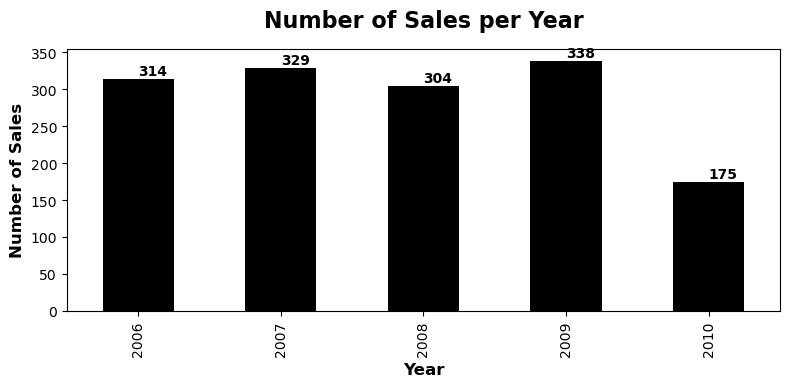

In [22]:
# house sales volume by year will consider feature `YrSold` and aggregate data on this
new_df = df_train.copy()

sales_volume = new_df.groupby(['YrSold']).size()

# Visualize by bar chart
sales_volume.plot(kind='bar', color="k", figsize=(8, 4))
# Annotate the text
for i, v in enumerate(sales_volume):
    plt.text(i, v+5, f"{v}", fontsize=10, fontweight='bold', color='k')


plt.title("Number of Sales per Year", fontsize=16, fontweight='bold', y=1.05)
plt.xlabel("Year", fontsize=12, fontweight='bold')
plt.ylabel("Number of Sales", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Number of houses sold per month across year**

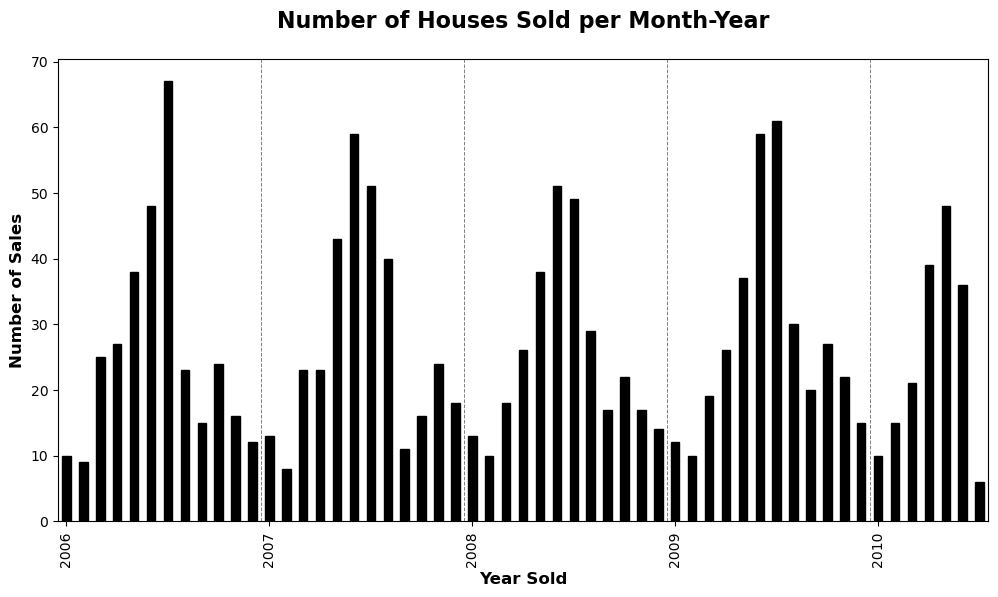

In [23]:
# Create proper datetime column
new_df['YearMonth'] = pd.to_datetime(
    new_df['YrSold'].astype(str) + '-' + new_df['MoSold'].astype(str),
    format='%Y-%m'
)

# Count sales per Year-Month
sales_counts = new_df.groupby('YearMonth').size().sort_index()

# Plot bar chart
fig, ax = plt.subplots(figsize=(12, 6))
sales_counts.plot(kind='bar', color='k', edgecolor='k', ax=ax)

# Replace x-axis ticks with years only
years = sales_counts.index.year.unique()
year_positions = [sales_counts.index.get_loc(sales_counts.index[sales_counts.index.year == y][0]) for y in years]

ax.set_xticks(year_positions)
ax.set_xticklabels(years)

# Add vertical lines to separate years
for pos in year_positions:
    ax.axvline(pos-0.5, color='gray', linestyle='--', linewidth=0.7)

plt.title("Number of Houses Sold per Month-Year", fontsize=16, fontweight='bold', y=1.05)
plt.xlabel("Year Sold", fontsize=12, fontweight='bold')
plt.ylabel("Number of Sales", fontsize=12, fontweight='bold')
plt.show()


We want to see when houses were bought between period 2006 and 2010. The first chart shows that sales stayed similar for the first four years, then dropped in 2010. To understand why this could be the case, we can look at the number of houses sold per month across these 5 years. When we look at the number of houses sold per month, we see two notable features. First, each year, June and July had the most sales, showing a clear summer peak. Next,the dip in 2010 happens because the data ends in July, so the rest of the year isn't available.

We started by looking at seasonal patterns in yearly sales. Now we'll apply time series techniques to confirm them. First, we observe how the sales volume per month has changed over time. Next,add exponential moving average (EMA) of sales volume over time. We will demonstrate this through line plot. 

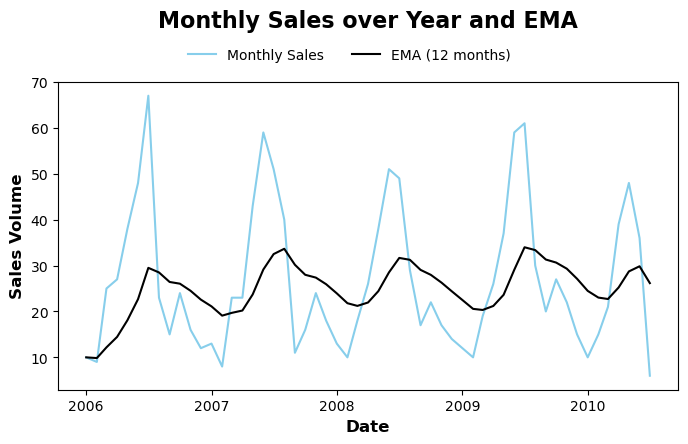

In [24]:
import matplotlib.dates as mdates

# plot line chart of volume per month over time
yearly_sales = sales_counts.reset_index(name='Count')

# compute exponential moving average(EMA)
yearly_sales['EMA'] = yearly_sales['Count'].ewm(span=12, adjust=False).mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(yearly_sales['YearMonth'], yearly_sales['Count'], color='skyblue', label="Monthly Sales")
ax.plot(yearly_sales['YearMonth'], yearly_sales['EMA'], color='k', label='EMA (12 months)')

# Force x-axis ticks to show only years
ax.xaxis.set_major_locator(mdates.YearLocator())          # one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # format as YYYY

ax.set_title("Monthly Sales over Year and EMA", fontsize=16, fontweight='bold', y=1.15)
ax.set_xlabel("Date", fontsize=12, fontweight='bold')
ax.set_ylabel("Sales Volume", fontsize=12, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(0.75, 1.15), ncol=2, frameon=False)
plt.show()

The chart shows monthly house sales in skyblue and their exponential moving average (EMA) in black. It highlights clear seasonal patterns: sales peak in the middle of each year, especially in summer, and drop sharply in between. These peaks match the earlier time series, suggesting that higher demand in summer may push prices up. Next, we examine how prices have changed over time.
We demonstrate this by plotting the average monthly sales price using the same method as before, with blue showing the raw series and black showing the EMA. Since the dataset only records the sale of each month, we will compute the average price per month and then applied the EMA with a 12‑month span. 

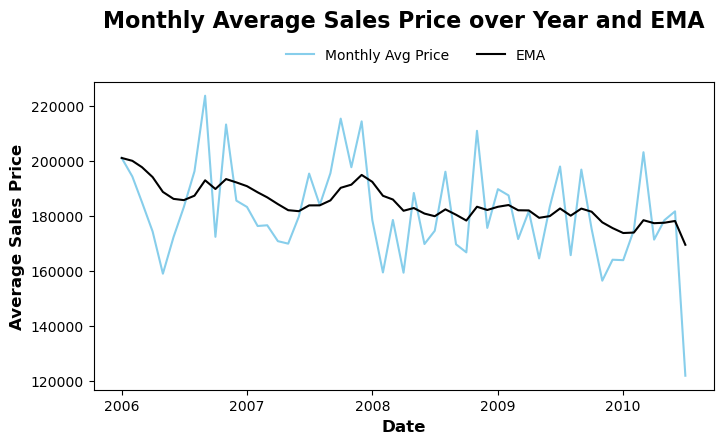

In [25]:
# Compute aggregate sale price of house per month over years
avg_saleprice = new_df.groupby(['YearMonth'])['SalePrice'].mean().sort_index().reset_index(name='Avg_saleprice')
avg_saleprice['EMA'] = avg_saleprice['Avg_saleprice'].ewm(span=12, adjust=False).mean()
avg_saleprice.head()

# Plot via line chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(avg_saleprice['YearMonth'], avg_saleprice['Avg_saleprice'], color='skyblue', label="Monthly Avg Price")
ax.plot(avg_saleprice['YearMonth'], avg_saleprice['EMA'], color='k', label='EMA')

# Force x-axis ticks to show only years
ax.xaxis.set_major_locator(mdates.YearLocator())          # one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # format as YYYY

ax.set_title("Monthly Average Sales Price over Year and EMA", fontsize=16, fontweight='bold', y=1.15)
ax.set_xlabel("Date", fontsize=12, fontweight='bold')
ax.set_ylabel("Average Sales Price", fontsize=12, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(0.75, 1.15), ncol=2, frameon=False)
plt.show()

The chart shows that prices in Ames have been slowly declining, though there are regular ups and downs. The EMA smooths out these short‑term swings, making the overall trend clearer. We also notice consistent peaks in average prices that match the peaks in the earlier sales volume chart. To explore these patterns further, we'll use seasonal decomposition of monthly prices and compare them with the sales volume series.

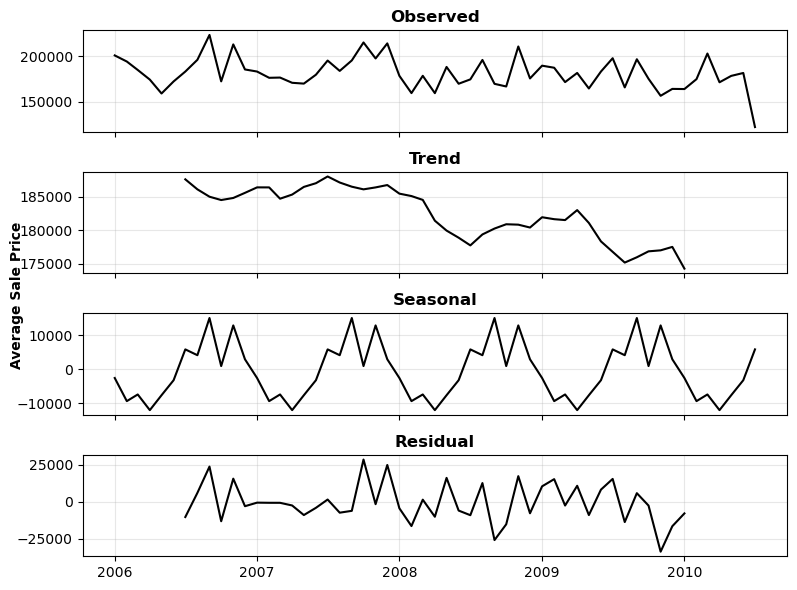

In [26]:
# To plot seasonal decomposition of monthly avg prices we will select YearMonth anf Avg_saleprice from avg_saleprice dataset 
monthly_sales = avg_saleprice[['YearMonth', 'Avg_saleprice']]

# Set datetime as index
monthly_sales = monthly_sales.set_index(['YearMonth'])

# Step 4: Seasonal decomposition (monthly frequency = 12)
decomposition = seasonal_decompose(monthly_sales['Avg_saleprice'], model='additive', period=12)

# Step 5: Plot decomposition
fig, ax = plt.subplots(4, 1, figsize=(8, 6), sharex=True)

ax[0].plot(decomposition.observed, color='k')
ax[0].set_title("Observed", fontweight='bold')
ax[0].grid(True, alpha=0.3)

ax[1].plot(decomposition.trend, color='k')
ax[1].set_title("Trend", fontweight='bold')
ax[1].grid(True, alpha=0.3)


ax[2].plot(decomposition.seasonal, color='k')
ax[2].set_title("Seasonal", fontweight='bold')
ax[2].grid(True, alpha=0.3)


ax[3].plot(decomposition.resid, color='k')
ax[3].set_title("Residual", fontweight='bold')
ax[3].grid(True, alpha=0.3)


fig.text(0.01, 0.5, "Average Sale Price", fontsize=10, fontweight='bold', va='center', rotation='vertical')

# Force x-axis ticks to show only years 
ax[3].xaxis.set_major_locator(mdates.YearLocator())          # one tick per year
ax[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # format as YYYY

plt.tight_layout()
plt.show()


The observed plot shows the raw time series, while the trend plot highlights the gradual decline in average prices we saw earlier. The seasonal plot clearly shows recurring peaks that match the sales volume series, likely reflecting higher demand in summer when people prefer to move, which can push prices up. The irregular plot doesn't reveal strong patterns beyond those peaks and looks quite similar to the raw series.

This shows that timing the housing market can benefit both buyers and sellers. In Ames, buyers tend to find lower prices in winter, while sellers can often secure higher prices during the summer.

__`Question 2.` In what ways have housing prices in Ames shifted over time, considering both market shocks and the age of homes?__

Our focus is on how the housing market turbulence between 2006 and 2010 influenced home sales in Ames, Iowa. Was the city shielded from these shocks, or did prices fall noticeably after 2007? To adjust for differences in property size, we analyze sale price per square foot.
Our goal is to see how average sale prices in Ames varied over time depending on when homes were sold. To adjust for differences in house size, we use price per square foot and apply a 6‑month rolling average. 

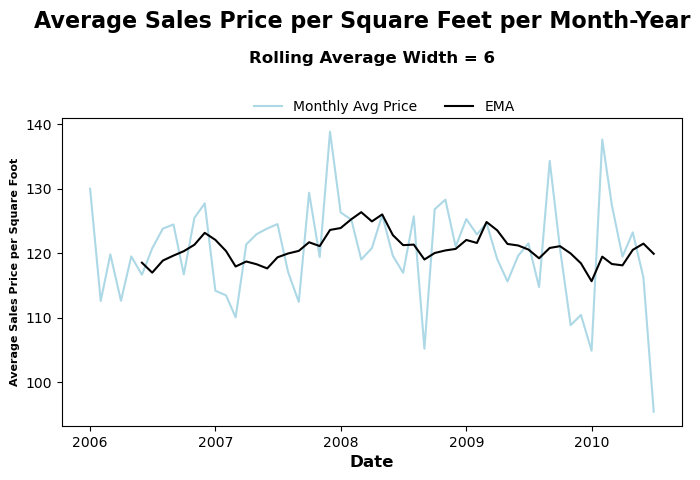

In [27]:
# Compute sale price per square foot
new_df['PricePerSF'] = new_df['SalePrice']/ new_df['GrLivArea']

# Compute avg price per sq. ft. per month-year 
avg_pricepersf = new_df.groupby(['YearMonth'])['PricePerSF'].mean().sort_index().reset_index(name='avg_sqft')
avg_pricepersf.head()

# Compute 6-month moving average
avg_pricepersf['Moving_avg'] = avg_pricepersf['avg_sqft'].rolling(window=6).mean()

# plotting
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(avg_pricepersf['YearMonth'], avg_pricepersf['avg_sqft'], color='lightblue', label="Monthly Avg Price")
ax.plot(avg_pricepersf['YearMonth'], avg_pricepersf['Moving_avg'], color='k', label='EMA')

# Force x-axis ticks to show only years
ax.xaxis.set_major_locator(mdates.YearLocator())          # one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # format as YYYY

fig.suptitle("Average Sales Price per Square Feet per Month-Year", fontsize=16, fontweight='bold', y=1.15)
ax.set_title("Rolling Average Width = 6", fontsize=12, fontweight='bold', y=1.15)
ax.set_xlabel("Date", fontsize=12, fontweight='bold')
ax.set_ylabel("Average Sales Price per Square Foot", fontsize=8, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(0.75, 1.10), ncol=2, frameon=False)
plt.show()

The results show some fluctuations but overall a mild downward trend between 2006 and 2010. This indicates that Ames was affected by the 2008 recession, though less severely than the broader housing market. That relative stability allows us to draw broader insights without being overly concerned about nationwide housing inflation or deflation during that period.

Since house sales show little variation across years and prices don't appear to depend much on the timing of the sale, we turn to examining whether a home's age and level of modernization influence its selling price.
Next, we explore how the sale price per square foot relates to the year a house was built, to see whether newer homes command higher prices. Simply relying on construction year isn't ideal, since many houses are remodeled or modernized over time. Instead, we use the year of the most recent remodel—or the build year if no remodel occurred—as a better measure. 

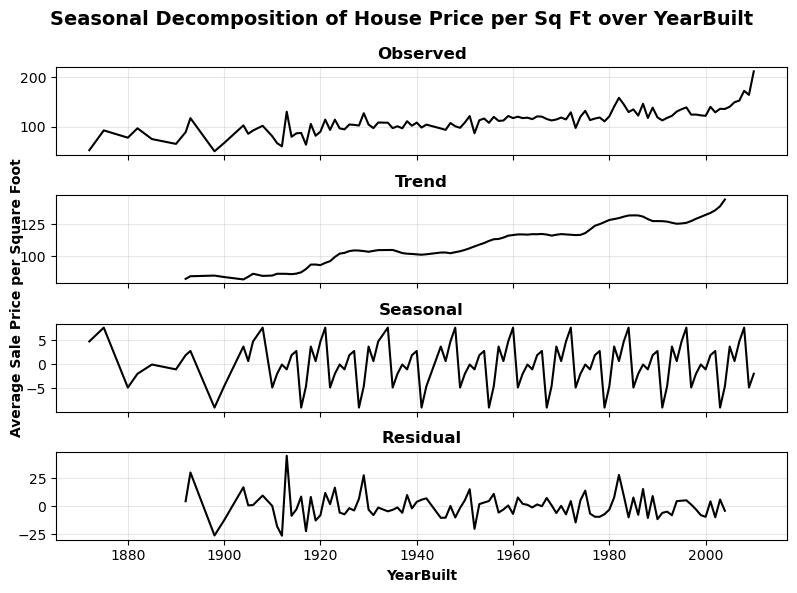

In [28]:
# selecting features : PricePerSF and YearBuilt for analysis
seasonal_df = new_df[['YearBuilt', 'PricePerSF']]

avg_pricesf = seasonal_df.groupby(['YearBuilt'])['PricePerSF'].mean().sort_index().reset_index(name='Avg_sqft')
# set datetime as index
avg_pricesf = avg_pricesf.set_index(['YearBuilt']).sort_index()

# Step 4: Seasonal decomposition (monthly frequency = 12)
decomposition = seasonal_decompose(avg_pricesf['Avg_sqft'], model='additive', period=12)

# Step 5: Plot decomposition
fig, ax = plt.subplots(4, 1, figsize=(8, 6), sharex=True)

ax[0].plot(decomposition.observed, color='k')
ax[0].set_title("Observed", fontweight='bold')
ax[0].grid(True, alpha=0.3)

ax[1].plot(decomposition.trend, color='k')
ax[1].set_title("Trend", fontweight='bold')
ax[1].grid(True, alpha=0.3)


ax[2].plot(decomposition.seasonal, color='k')
ax[2].set_title("Seasonal", fontweight='bold')
ax[2].grid(True, alpha=0.3)


ax[3].plot(decomposition.resid, color='k')
ax[3].set_title("Residual", fontweight='bold')
ax[3].grid(True, alpha=0.3)


fig.text(0.01, 0.5, "Average Sale Price per Square Foot", fontsize=10, fontweight='bold', va='center', rotation='vertical')

fig.suptitle("Seasonal Decomposition of House Price per Sq Ft over YearBuilt", fontsize=14, fontweight='bold')

ax[3].set_xlabel("YearBuilt", fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


The seasonal decomposition plot reveals a clear upward trend, showing that more recently built or remodeled homes tend to sell for higher prices. The third plot, representing seasonality component, highlights fluctuations with peaks and valleys, likely reflecting natural cycles in the housing market.

# **Conclusion**

First, we look at seasonal trend in sales volume and price and concluded that both home sales volume and prices show seasonal patterns, with certain times of the year bringing more activity and noticeable price changes.

Second, we explored the impact of market shocks revealed a modest effect of the 2008 recession on housing prices in Ames and the seasonal decomposition showing that more recently built or remodeled homes tend to sell for higher prices.